# Random ML Task

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv('global_street_food.csv')

In [70]:
df.head()

,Dish Name,Country,Region/City,Ingredients,Description,Cooking Method,Typical Price (USD),Vegetarian
0,Takoyaki,Japan,Osaka,"Octopus, Flour Batter, Bonito Flakes, Green On...","Crispy and hot, often served with sauces or ch...",Fried,3.28,No
1,Vada Pav,India,Mumbai,"Potato, Spices, Bread Bun, Chutney","Crispy and hot, often served with sauces or ch...",Fried,2.37,Yes
2,Funnel Cake,USA,Texas,"Batter, Sugar, Oil","Crispy and hot, often served with sauces or ch...",Fried,2.78,Yes
3,Kathi Roll,India,Kolkata,"Flatbread, Egg, Chicken, Onions, Chutney",Charred to perfection with a smoky flavor.,Grilled,1.89,No
4,Pad Thai,Thailand,Bangkok,"Rice Noodles, Tofu, Eggs, Peanuts, Bean Sprouts",Quickly tossed in a hot pan with bold flavors.,Stir-Fried,3.48,Yes


In [71]:
df.isnull().sum()

Dish Name              0
Country                0
Region/City            0
Ingredients            0
Description            0
Cooking Method         0
Typical Price (USD)    0
Vegetarian             0
dtype: int64

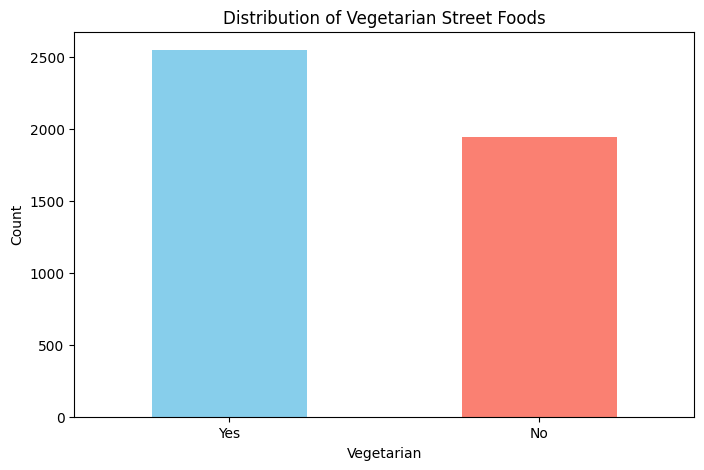

In [72]:
# plot distribution of Vegetarian column
plt.figure(figsize=(8,5))
df['Vegetarian'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Vegetarian Street Foods')
plt.xlabel('Vegetarian')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

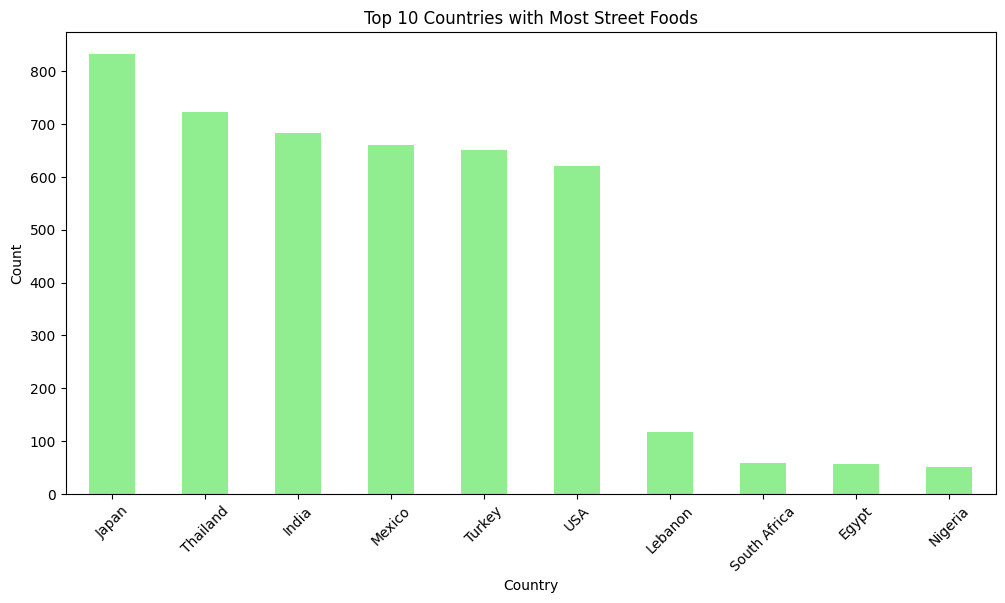

In [73]:
# plot distribution of Country column
plt.figure(figsize=(12,6))
df['Country'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title('Top 10 Countries with Most Street Foods')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


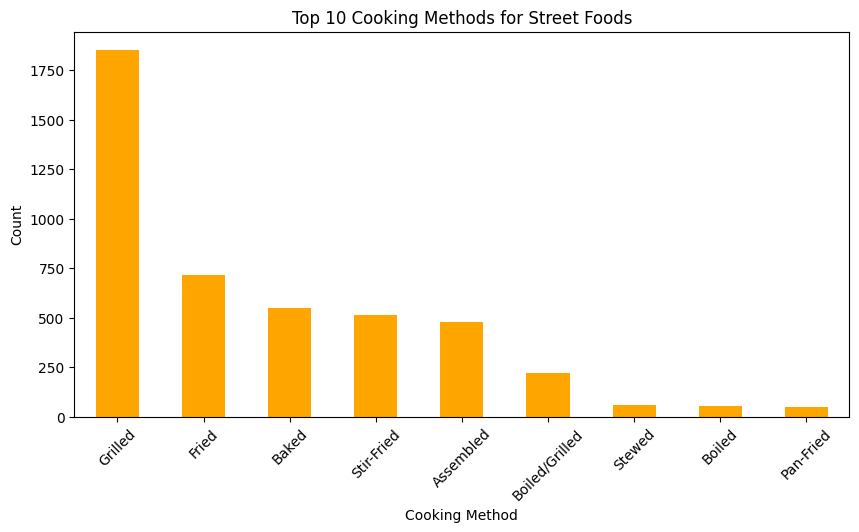

In [74]:
# plot distribution of cooking method column
plt.figure(figsize=(10,5))
df['Cooking Method'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Cooking Methods for Street Foods')
plt.xlabel('Cooking Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [75]:
# show dtype of each column
df.dtypes

Dish Name               object
Country                 object
Region/City             object
Ingredients             object
Description             object
Cooking Method          object
Typical Price (USD)    float64
Vegetarian              object
dtype: object

# How you want to cook your food? 😋

1. Pre-processing

In [76]:
df = df.drop_duplicates()

In [81]:
X = df[['Ingredients','Description','Vegetarian']]
y = df['Cooking Method']

In [82]:
X.shape, y.shape

((3212, 3), (3212,))

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# save the label encoder for future use
le = LabelEncoder()
y = le.fit_transform(y)
# Save the fitted encoder
import pickle
with open('label_encoder_2.pkl', 'wb') as le_file:
    pickle.dump(le, le_file)



In [84]:
print(le.classes_)

['Assembled' 'Baked' 'Boiled' 'Boiled/Grilled' 'Fried' 'Grilled'
 'Pan-Fried' 'Stewed' 'Stir-Fried']


In [85]:
X['Ingredients'][4]

'Rice Noodles, Tofu, Eggs, Peanuts, Bean Sprouts'

2. Feature Engineering

In [86]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=300)

In [87]:
X['Vegetarian'] = X['Vegetarian'].map({'Yes': 1, 'No': 0})

x_ingredients = tfidf.fit_transform(X['Ingredients']).toarray()
x_description = tfidf.fit_transform(X['Description']).toarray()

X_final = np.concatenate([x_ingredients, x_description, X[['Vegetarian']].values], axis=1)
X_final.shape

C:\Users\itzch\AppData\Local\Temp\ipykernel_28428\3571090646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Vegetarian'] = X['Vegetarian'].map({'Yes': 1, 'No': 0})


(3212, 140)

In [88]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2569, 140), (643, 140), (2569,), (643,))

3. Model Building

In [89]:
import tensorflow as tf
from tensorflow.keras import layers, models   

In [90]:
model = models.Sequential()
model.add(layers.InputLayer(input_shape=(X_train.shape[1],)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dense(len(np.unique(y)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 16)                2256      
                                                                 
 dense_16 (Dense)            (None, 4)                 68        
                                                                 
 dense_17 (Dense)            (None, 9)                 45        
                                                                 
Total params: 2,369
Trainable params: 2,369
Non-trainable params: 0
_________________________________________________________________


In [91]:
with tf.device('/GPU:0'):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
65/65 [==============================] - 1s 9ms/step - loss: 2.0307 - accuracy: 0.5192 - val_loss: 1.7894 - val_accuracy: 0.7354
Epoch 2/20
65/65 [==============================] - 0s 6ms/step - loss: 1.4301 - accuracy: 0.7377 - val_loss: 1.0864 - val_accuracy: 0.7471
Epoch 3/20
65/65 [==============================] - 0s 6ms/step - loss: 0.7609 - accuracy: 0.8735 - val_loss: 0.5772 - val_accuracy: 0.8658
Epoch 4/20
65/65 [==============================] - 0s 6ms/step - loss: 0.4110 - accuracy: 0.8847 - val_loss: 0.3494 - val_accuracy: 0.8658
Epoch 5/20
65/65 [==============================] - 0s 6ms/step - loss: 0.2491 - accuracy: 0.9630 - val_loss: 0.2130 - val_accuracy: 0.9981
Epoch 6/20
65/65 [==============================] - 0s 6ms/step - loss: 0.1350 - accuracy: 0.9990 - val_loss: 0.0999 - val_accuracy: 0.9981
Epoch 7/20
65/65 [==============================] - 0s 6ms/step - loss: 0.0602 - accuracy: 0.9990 - val_loss: 0.0488 - val_accuracy: 0.9981
Epoch 8/20
65/65 [==

In [92]:
# Save the model
model.save('street_food_model.h5')

4. Evaluation

In [93]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

21/21 [==============================] - 0s 5ms/step - loss: 0.0045 - accuracy: 0.9984
Test Accuracy: 0.9984
Test Loss: 0.0045


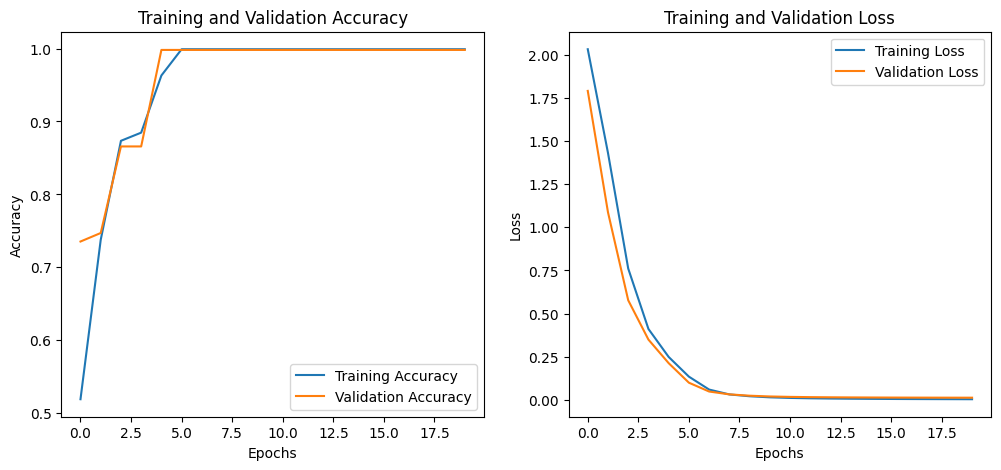

In [94]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

21/21 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        40
           4       1.00      1.00      1.00       120
           5       1.00      1.00      1.00       285
           8       0.99      1.00      0.99        70

    accuracy                           1.00       643
   macro avg       1.00      1.00      1.00       643
weighted avg       1.00      1.00      1.00       643

[[ 70   0   0   0   0   0]
 [  0  58   0   0   0   0]
 [  0   0  40   0   0   0]
 [  0   0   0 120   0   0]
 [  0   0   0   0 284   1]
 [  0   0   0   0   0  70]]


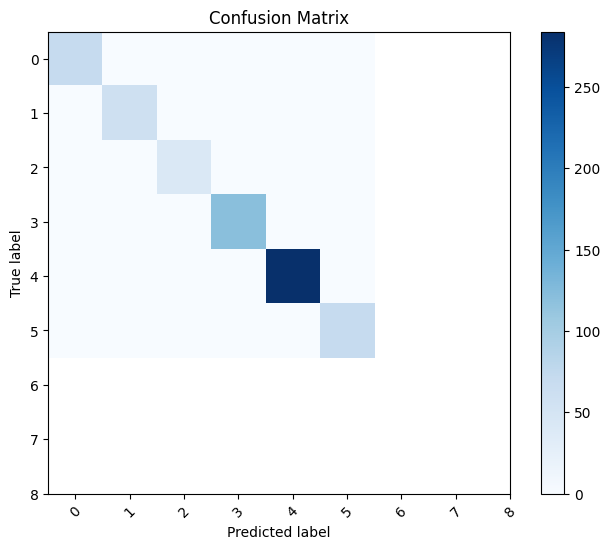

In [95]:
# Evaluate the model with classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
y_pred = np.argmax(model.predict(X_test), axis=-1)
print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(y)))
plt.xticks(tick_marks, np.unique(y), rotation=45)
plt.yticks(tick_marks, np.unique(y))
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

5. Prediction

In [97]:
def pad_features(arr, target_length):
    # Pads with zeros if arr is shorter than target_length
    if arr.shape[1] < target_length:
        pad_width = target_length - arr.shape[1]
        arr = np.pad(arr, ((0,0),(0,pad_width)), 'constant')
    return arr

def predict_cooking_method(ingredients, description, vegetarian):
    import numpy as np
    import pickle
    from tensorflow.keras.models import load_model

    model = load_model('street_food_model.h5')
    with open('label_encoder_2.pkl', 'rb') as le_file:
        le = pickle.load(le_file)
    with open('tfidf_vectorizer.pkl', 'rb') as tfidf_file:
        tfidf = pickle.load(tfidf_file)

    x_ingredients = tfidf.transform([ingredients]).toarray()
    x_description = tfidf.transform([description]).toarray()
    vegetarian_value = 1 if vegetarian.lower() == 'yes' else 0

    # Pad both features to expected length (e.g., 140/2 = 70 each if split, or 139+1)
    x_ingredients = pad_features(x_ingredients, 69)
    x_description = pad_features(x_description, 70)
    input_data = np.concatenate([x_ingredients, x_description, np.array([[vegetarian_value]])], axis=1)

    # If needed, pad input_data to 140
    input_data = pad_features(input_data, 140)

    prediction = model.predict(input_data)
    predicted_class = np.argmax(prediction, axis=-1)
    cooking_method = le.inverse_transform(predicted_class)
    return cooking_method[0]


# Take user input and predict
name = input("Enter the street food name: ")
ingredients = input("Enter the ingredients: ")
description = input("Enter the description: ")
vegetarian = input("Is it vegetarian? (Yes/No): ")

predicted_method = predict_cooking_method(
    ingredients=ingredients,
    description=description,
    vegetarian=vegetarian
)
print(f"You should cook '{name}' using the '{predicted_method}' method.")


1/1 [==============================] - 0s 72ms/step
You should cook 'Noodles' using the 'Grilled' method.
